In [1]:
import os
import os.path
from natsort import natsorted
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

Step: 1000

Experiment: original_pretrained_sd1.4_bf16


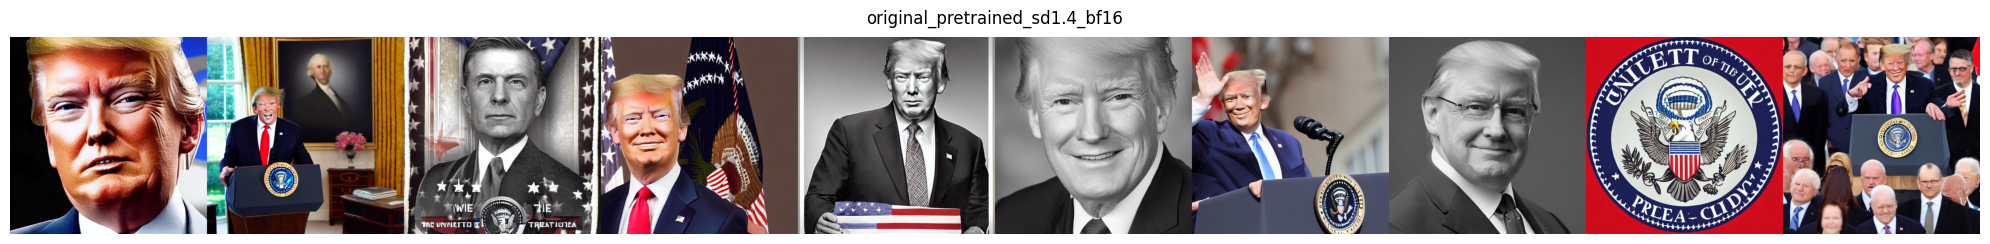


Experiment: esd-x.bG.fG_U.dtrump_sd1.4.bf16.bs4_r0


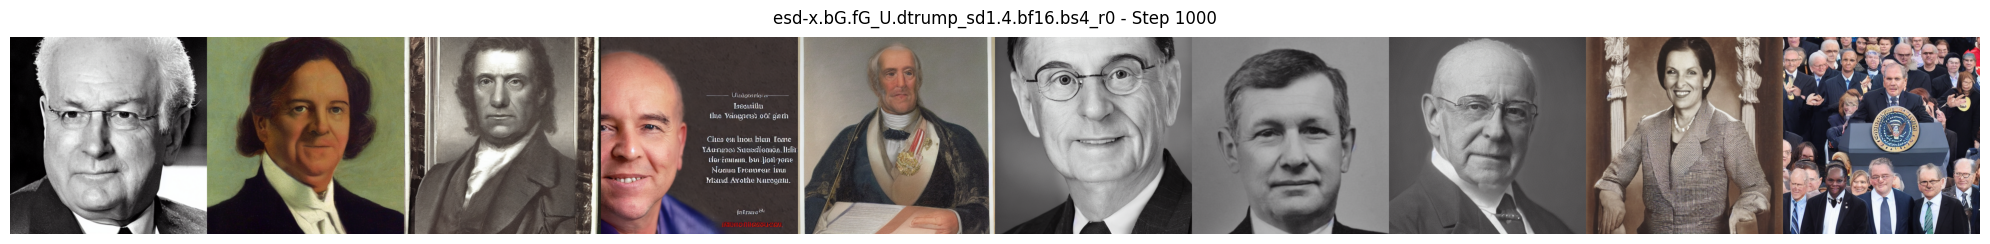


Experiment: esd-s.bG.fG_U.dtrump_sd1.4.bf16.bs4_r0


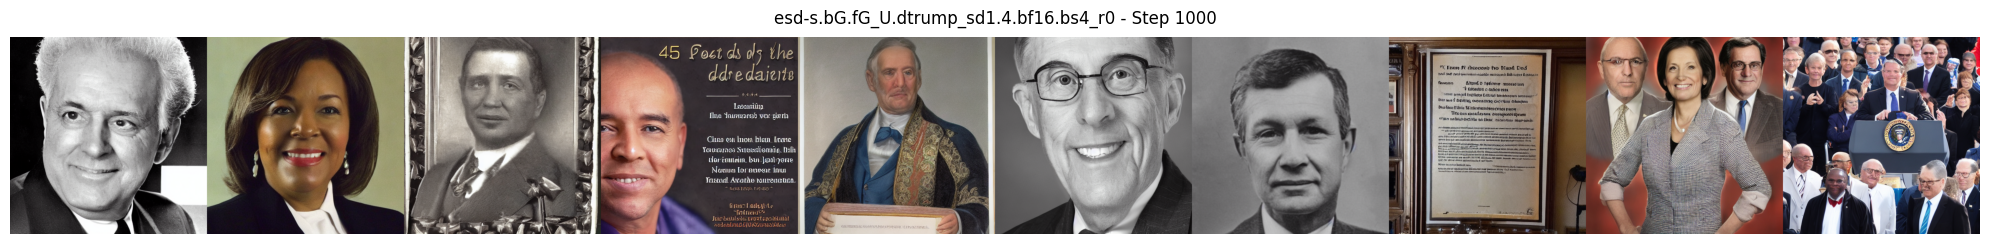


Experiment: esd-xs.bG.fG_U.dtrump_sd1.4.bf16.bs4_r0


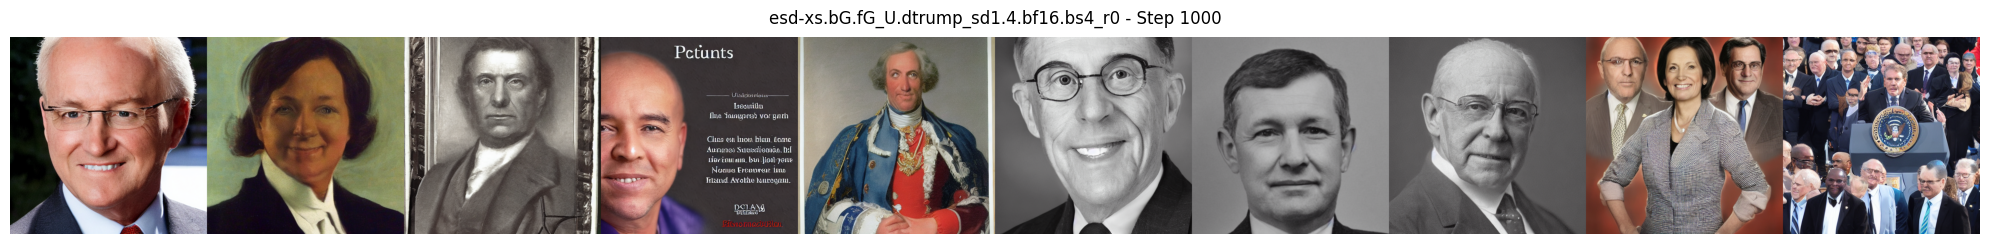


Experiment: esd-u.bG.fG_U.dtrump_sd1.4.bf16.bs4_r0


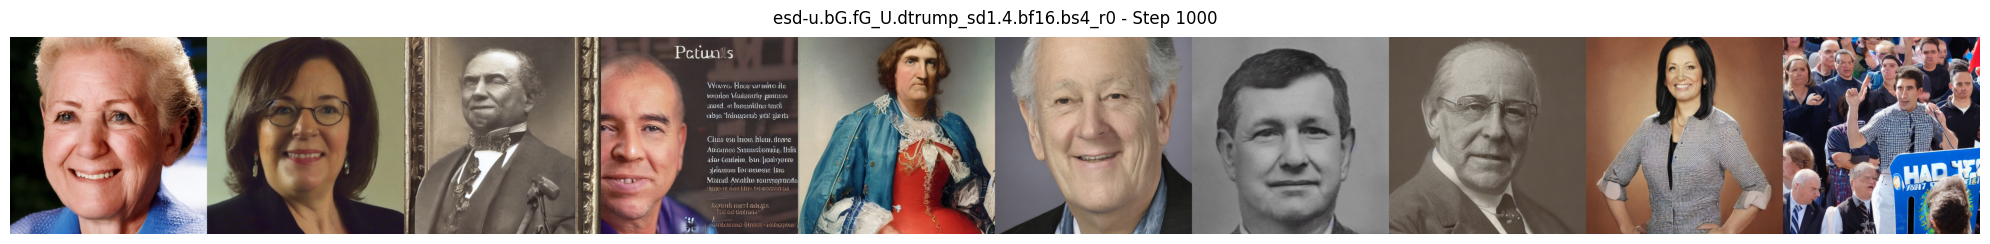

In [39]:
concept = 'dtrump'
exp_names = [
    'original_pretrained_sd1.4_bf16',
    # f'esd-x.bG.fG_U.{concept}_sd1.4.bf16.bs4_r0',
    # f'esd-x.fU_U.{concept}_sd1.4.bf16.bs4_r0',

    # f'esd-x.nG3.00.bG.fG_U.{concept}_sd1.4.bf16.bs4_r0',
    # f'esd-x.nG3.00.fU_U.{concept}_sd1.4.bf16.bs4_r0',
    
    # f'duo-s_U.{concept}_sd1.4.bf16.bs4_r0',
    # f'stereo_U.{concept}_sd1.4.bf16.bs4_r0',
    
    
    f'esd-x.bG.fG_U.{concept}_sd1.4.bf16.bs4_r0',
    f'esd-s.bG.fG_U.{concept}_sd1.4.bf16.bs4_r0',
    f'esd-xs.bG.fG_U.{concept}_sd1.4.bf16.bs4_r0',
    f'esd-u.bG.fG_U.{concept}_sd1.4.bf16.bs4_r0',
    
    
    
]

# prompt = 'a photo of Donald Trump'
# prompt = 'a photo of Mitch McConnell'
# prompt = 'a photo of Bernie Sanders'
# prompt = 'a photo of Melania Trump'
# prompt = 'a photo of Donald Trump in disneyland'
# prompt = 'a photo of Donald Trump in disneyland'
# prompt = 'a photo of Leonardo DiCaprio'
# prompt = 'a photo of person'
# prompt = 'a photo of mickey mouse'
prompt = 'a photo of the 45th president of the united states'
steps= [1000]
n_sample = 10

root_img_dir = "data_root/generated/study"

for step in steps:
    print(f"Step: {step}")
    for exp_name in exp_names:
        print(f"\n{'='*80}")
        print(f"Experiment: {exp_name}")
        print(f"{'='*80}")
        
        if exp_name == 'original_pretrained_sd1.4_bf16':
            img_dir = f"{root_img_dir}/{exp_name}/{prompt}/7.50"
        else:
            # step = steps[0]
            img_dir = f"{root_img_dir}/{exp_name}/step{step}/{prompt}/7.50"
        
        # Load images
        img_files = natsorted(os.listdir(img_dir))[:n_sample]
        images = [Image.open(os.path.join(img_dir, f)) for f in img_files]
        
        # Concatenate images horizontally
        widths, heights = zip(*(img.size for img in images))
        total_width = sum(widths)
        max_height = max(heights)
        
        concatenated = Image.new('RGB', (total_width, max_height))
        x_offset = 0
        for img in images:
            concatenated.paste(img, (x_offset, 0))
            x_offset += img.width
        
        # Display
        plt.figure(figsize=(20, 4))
        plt.imshow(concatenated)
        plt.axis('off')
        plt.title(f"{exp_name} - Step {step}" if exp_name != 'original_pretrained_sd1.4_bf16' else exp_name, fontsize=12, pad=10)
        plt.tight_layout()
        plt.show()